# NLP Assessment 3 - Mental Health Signal Detection
Group members: Dylan Chum

This notebook fine-tunes DistilBERT on Reddit posts to classify depression vs non-depression signals.

# 1. Setup


In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"GPU name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Using device: cuda
GPU name: Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

folder = '/content/drive/MyDrive/NLP Experiment'
print(f"Folder exists: {os.path.exists(folder)}")

if os.path.exists(folder):
    print(f"\nFiles in folder:")
    for f in os.listdir(folder):
        print(f"  - {f}")
else:
    print("\nFolder not found. Listing MyDrive root:")
    for f in os.listdir('/content/drive/MyDrive'):
        print(f"  - {f}")

Folder exists: True

Files in folder:
  - depression_dataset_reddit_cleaned.csv
  - figures
  - nlp_a3_depression_detection.ipynb


## 2. Load Dataset


In [4]:
!pip install transformers datasets scikit-learn matplotlib seaborn -q

import pandas as pd
import numpy as np
import torch
from transformers import (
    DistilBertTokenizer, DistilBertForSequenceClassification,
    Trainer, TrainingArguments
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
import pandas as pd

file_path = '/content/drive/MyDrive/NLP Experiment/depression_dataset_reddit_cleaned.csv'

df = pd.read_csv(file_path)

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (7731, 2)

Columns: ['clean_text', 'is_depression']

First 3 rows:


,clean_text,is_depression
0,we understand that most people who reply immed...,1
1,welcome to r depression s check in post a plac...,1
2,anyone else instead of sleeping more when depr...,1


## 3. Exploratory Data Analysis


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df.isnull().sum())
print()
print(df['is_depression'].value_counts())
print(df['is_depression'].value_counts(normalize=True).round(3))

clean_text       0
is_depression    0
dtype: int64

is_depression
0    3900
1    3831
Name: count, dtype: int64
is_depression
0    0.504
1    0.496
Name: proportion, dtype: float64


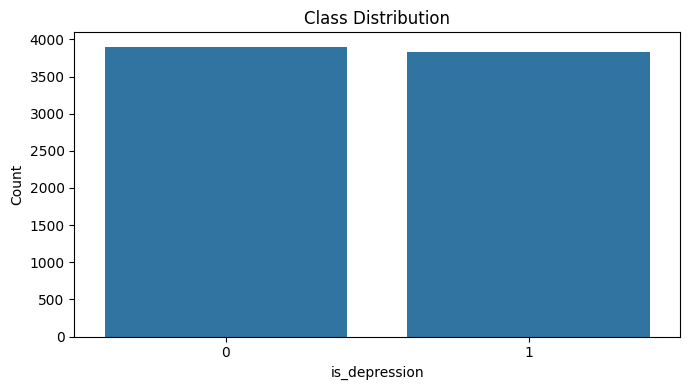

In [7]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='is_depression')
plt.title('Class Distribution')
plt.xlabel('is_depression')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

In [8]:
df['word_count'] = df['clean_text'].astype(str).apply(lambda x: len(x.split()))

print(df['word_count'].describe().round(1))
print()
print(df.groupby('is_depression')['word_count'].mean().round(1))

count    7731.0
mean       74.6
std       144.4
min         1.0
25%        12.0
50%        22.0
75%        76.0
max      4239.0
Name: word_count, dtype: float64

is_depression
0     14.3
1    136.1
Name: word_count, dtype: float64


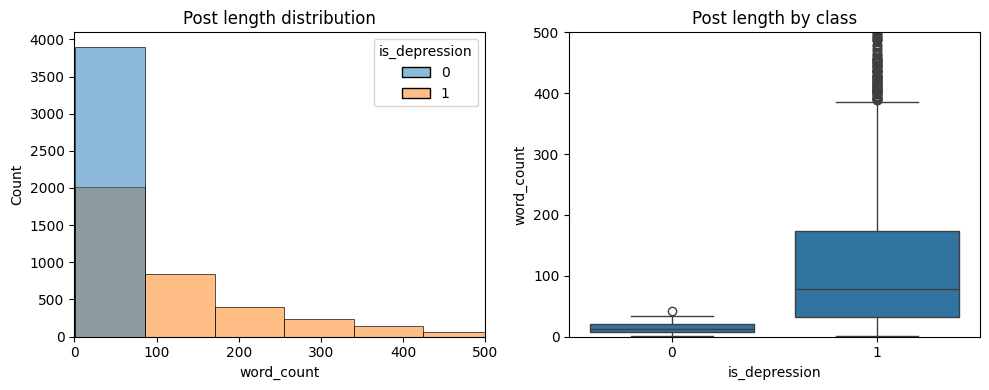

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(data=df, x='word_count', hue='is_depression', bins=50, ax=axes[0])
axes[0].set_xlim(0, 500)
axes[0].set_title('Post length distribution')

sns.boxplot(data=df, x='is_depression', y='word_count', ax=axes[1])
axes[1].set_ylim(0, 500)
axes[1].set_title('Post length by class')

plt.tight_layout()
plt.savefig('post_length.png', dpi=150)
plt.show()

In [10]:
print("Non-depression samples:")
for post in df[df['is_depression'] == 0]['clean_text'].sample(2, random_state=42).values:
    print("-", post[:250])

print("\nDepression samples:")
for post in df[df['is_depression'] == 1]['clean_text'].sample(2, random_state=42).values:
    print("-", post[:250])

Non-depression samples:
- can t sleep i hate these night when i try to go to bed early and stay awake for hour poo
- home mc bored missing him who him sigh im bored tadi exam amp wa okay thursday lagi exam gaaaaaaaaaaaaaahhh

Depression samples:
- i m not depressed or in depression i think there is a lot to live for in life actually but lately i ve been having thought of suicide it s not every hour of every day but something will happen and i ll just casually think to myself what the hell f ck
- i used to enjoy posting and just interacting with people but now i can t bring myself to open it up it s just awful seeing post and post of people just living while i m just existing stagnant it all feel so counterfeit


## 4. Preprocessing

In [11]:
from sklearn.model_selection import train_test_split

X = df['clean_text'].astype(str).tolist()
y = df['is_depression'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train)}")
print(f"Val:   {len(X_val)}")
print(f"Test:  {len(X_test)}")

Train: 5411
Val:   1160
Test:  1160


In [12]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

MAX_LEN = 128

train_enc = tokenizer(X_train, truncation=True, padding=True, max_length=MAX_LEN, return_tensors='pt')
val_enc   = tokenizer(X_val,   truncation=True, padding=True, max_length=MAX_LEN, return_tensors='pt')
test_enc  = tokenizer(X_test,  truncation=True, padding=True, max_length=MAX_LEN, return_tensors='pt')

print(train_enc['input_ids'].shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

torch.Size([5411, 128])


In [13]:
import torch
from torch.utils.data import Dataset

class RedditDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_ds = RedditDataset(train_enc, y_train)
val_ds   = RedditDataset(val_enc, y_val)
test_ds  = RedditDataset(test_enc, y_test)

## 5. Baseline: TF-IDF + Logistic Regression

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

baseline = LogisticRegression(max_iter=1000, class_weight='balanced')
baseline.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [15]:
y_pred_baseline = baseline.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_baseline, target_names=['Non-depression', 'Depression']))

                precision    recall  f1-score   support

Non-depression       0.93      0.98      0.95       585
    Depression       0.97      0.92      0.95       575

      accuracy                           0.95      1160
     macro avg       0.95      0.95      0.95      1160
  weighted avg       0.95      0.95      0.95      1160



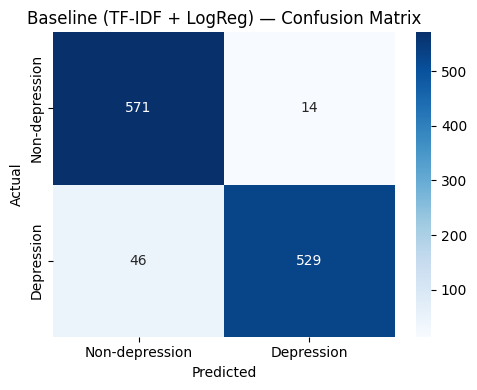

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-depression', 'Depression'],
            yticklabels=['Non-depression', 'Depression'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Baseline (TF-IDF + LogReg) — Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix_baseline.png', dpi=150)
plt.show()

## 6. Fine-tune DistilBERT

In [17]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print(class_weights)

tensor([0.9910, 1.0091], device='cuda:0')


In [18]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
).to(device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [19]:
from transformers import Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch.nn as nn

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=1)
    labels = eval_pred.label_ids
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

In [20]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=100,
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    report_to='none'
)

In [21]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.100930,0.065970,0.978448,0.978166,0.982456,0.973913
2,0.071280,0.061381,0.981034,0.980736,0.987654,0.973913
3,0.021893,0.076192,0.979310,0.979275,0.972556,0.986087


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1017, training_loss=0.1000974737730467, metrics={'train_runtime': 220.714, 'train_samples_per_second': 73.548, 'train_steps_per_second': 4.608, 'total_flos': 537585820595712.0, 'train_loss': 0.1000974737730467, 'epoch': 3.0})

## 7. Evaluation

In [34]:
predictions = trainer.predict(test_ds)
y_pred_bert = np.argmax(predictions.predictions, axis=1)

print(classification_report(y_test, y_pred_bert, target_names=['Non-depression', 'Depression']))

                precision    recall  f1-score   support

Non-depression       0.97      0.99      0.98       585
    Depression       0.99      0.97      0.98       575

      accuracy                           0.98      1160
     macro avg       0.98      0.98      0.98      1160
  weighted avg       0.98      0.98      0.98      1160



In [35]:
print(classification_report(y_test, y_pred_baseline, target_names=['Non-depression', 'Depression']))

                precision    recall  f1-score   support

Non-depression       0.93      0.98      0.95       585
    Depression       0.97      0.92      0.95       575

      accuracy                           0.95      1160
     macro avg       0.95      0.95      0.95      1160
  weighted avg       0.95      0.95      0.95      1160



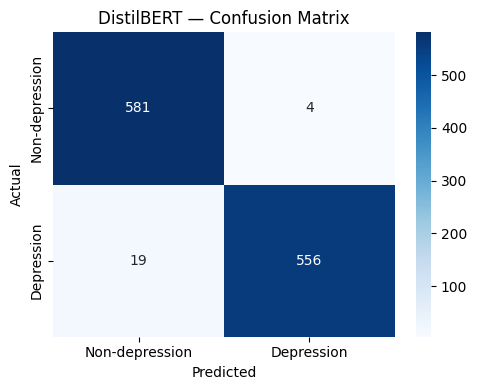

In [36]:
cm_bert = confusion_matrix(y_test, y_pred_bert)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-depression', 'Depression'],
            yticklabels=['Non-depression', 'Depression'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('DistilBERT — Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix_bert.png', dpi=150)
plt.show()

In [37]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def get_metrics(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    acc = accuracy_score(y_true, y_pred)
    return acc, p, r, f

baseline_metrics = get_metrics(y_test, y_pred_baseline)
bert_metrics = get_metrics(y_test, y_pred_bert)

results_df = pd.DataFrame({
    'Model': ['TF-IDF + LogReg', 'DistilBERT'],
    'Accuracy': [baseline_metrics[0], bert_metrics[0]],
    'Precision': [baseline_metrics[1], bert_metrics[1]],
    'Recall': [baseline_metrics[2], bert_metrics[2]],
    'F1': [baseline_metrics[3], bert_metrics[3]]
}).round(4)

print(results_df.to_string(index=False))

          Model  Accuracy  Precision  Recall     F1
TF-IDF + LogReg    0.9483     0.9742   0.920 0.9463
     DistilBERT    0.9802     0.9929   0.967 0.9797


## 8. Visualisation

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


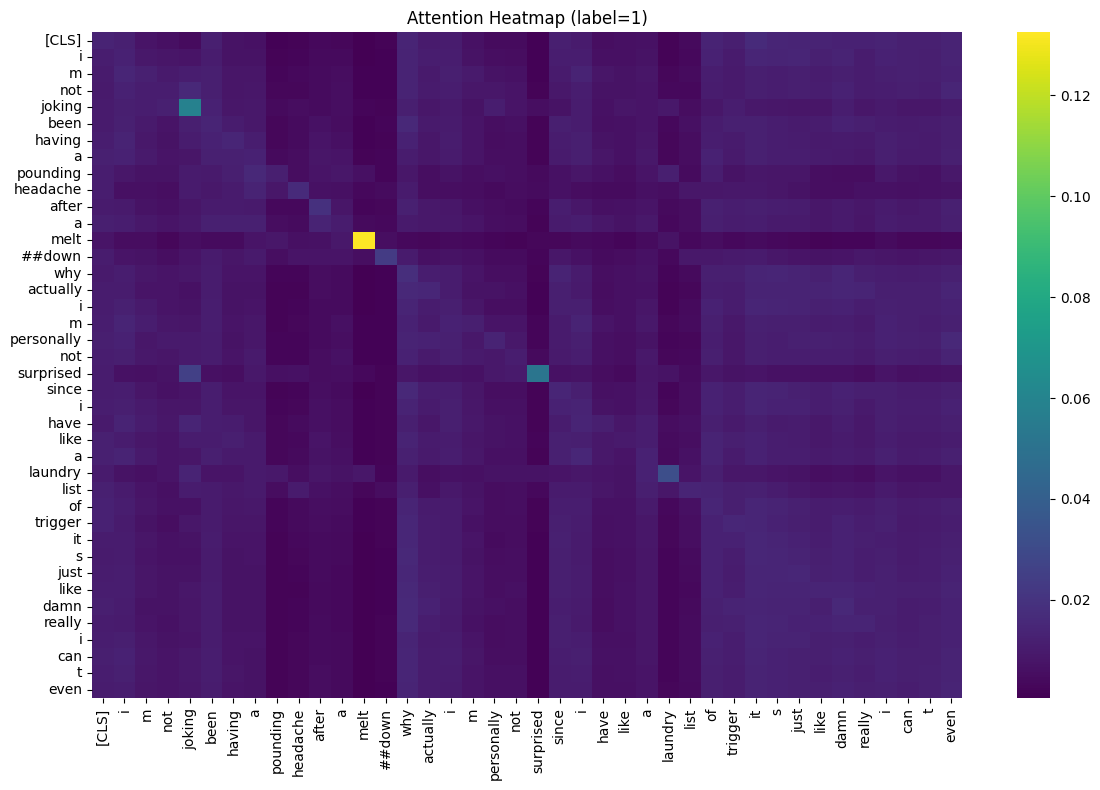


Post: i m not joking been having a pounding headache after a meltdown why actually i m personally not surprised since i have like a laundry list of trigger it s just like damn really i can t even cry in peace depression is a bitch weirder part is if you are cutting onion or even cry because something good
True label: 1


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

attn_model = DistilBertForSequenceClassification.from_pretrained(
    './results/checkpoint-best',
    attn_implementation='eager'
).to(device) if False else None

from transformers import DistilBertConfig

config = DistilBertConfig.from_pretrained('distilbert-base-uncased', num_labels=2, attn_implementation='eager')
attn_model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', config=config).to(device)
attn_model.load_state_dict(model.state_dict())
attn_model.eval()

sample_idx = 0
sample_text = X_test[sample_idx]
sample_label = y_test[sample_idx]

inputs = tokenizer(sample_text, return_tensors='pt', truncation=True, max_length=128, padding=True).to(device)

with torch.no_grad():
    outputs = attn_model(**inputs, output_attentions=True)

attentions = outputs.attentions[-1][0].mean(dim=0).cpu().numpy()
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

n = min(40, len(tokens))
plt.figure(figsize=(12, 8))
sns.heatmap(attentions[:n, :n], xticklabels=tokens[:n], yticklabels=tokens[:n], cmap='viridis')
plt.title(f'Attention Heatmap (label={sample_label})')
plt.tight_layout()
plt.savefig('attention_heatmap.png', dpi=150)
plt.show()

print(f"\nPost: {sample_text[:300]}")
print(f"True label: {sample_label}")

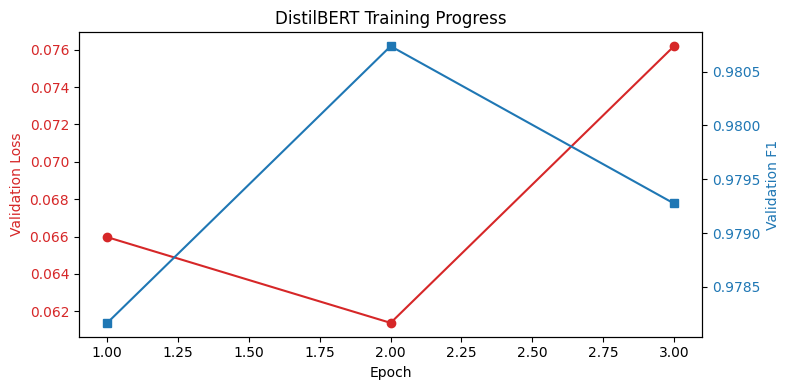

In [26]:
import pandas as pd

log_history = trainer.state.log_history
train_loss = [(x['step'], x['loss']) for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_metrics = [(x['epoch'], x.get('eval_loss'), x.get('eval_f1')) for x in log_history if 'eval_loss' in x]

eval_df = pd.DataFrame(eval_metrics, columns=['epoch', 'eval_loss', 'eval_f1']).dropna()

fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(eval_df['epoch'], eval_df['eval_loss'], 'o-', color='tab:red', label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Validation Loss', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.plot(eval_df['epoch'], eval_df['eval_f1'], 's-', color='tab:blue', label='Validation F1')
ax2.set_ylabel('Validation F1', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('DistilBERT Training Progress')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## 9. Error Analysis

In [27]:
errors = []
for i, (true, pred) in enumerate(zip(y_test, y_pred_bert)):
    if true != pred:
        errors.append({
            'text': X_test[i][:250],
            'true': true,
            'predicted': pred
        })

errors_df = pd.DataFrame(errors)
print(f"Total errors: {len(errors_df)} out of {len(y_test)}")
print(f"\nFalse Positives (predicted depression, actually not):")
print(errors_df[errors_df['true'] == 0].head(3).to_string(index=False))
print(f"\nFalse Negatives (missed depression):")
print(errors_df[errors_df['true'] == 1].head(3).to_string(index=False))

Total errors: 23 out of 1160

False Positives (predicted depression, actually not):
                                                                                                                        text  true  predicted
i am so screwed up a confused and dumb child i never felt so bad all my life i wish i have any specialty too bad i have none     0          1
                                                                                        too much to do not enough motivation     0          1
                                                                                                        you ve all failed me     0          1

False Negatives (missed depression):
                                                     text  true  predicted
        i m so scared of you these day i miss being happy     1          0
when i slit my wrist we will see it s a 0 0 at this point     1          0
                                  filler text filler tezt     1          0


In [39]:
import shutil, os

os.makedirs('/content/drive/MyDrive/NLP Experiment/figures', exist_ok=True)

for fname in ['class_distribution.png', 'post_length.png',
              'confusion_matrix_baseline.png', 'confusion_matrix_bert.png',
              'attention_heatmap.png', 'training_curves.png']:
    if os.path.exists(fname):
        shutil.copy(fname, f'/content/drive/MyDrive/NLP Experiment/figures/{fname}')
        print(f"Saved: {fname}")

Saved: class_distribution.png
Saved: post_length.png
Saved: confusion_matrix_baseline.png
Saved: confusion_matrix_bert.png
Saved: attention_heatmap.png
Saved: training_curves.png


In [40]:
results_df.to_csv('/content/drive/MyDrive/NLP Experiment/results_comparison.csv', index=False)
print("Results saved.")

Results saved.
